# Лабораторная работа №6

Анимация динамики SIR-сети Петри

Закиров Нурислам Дамирович (РУДН)

# Цель

Создать GIF-анимацию, показывающую изменение численности групп `S`, `I`,
`R` во времени.

# Загрузка проекта

In [1]:
using DrWatson
@quickactivate "project"

using Plots

include(srcdir("SIRPetri.jl"))
using .SIRPetri

# Моделирование

In [2]:
β = 0.3
γ = 0.1
tmax = 100.0

net, u0, _ = build_sir_network(β, γ)
df = simulate_deterministic(net, u0, (0.0, tmax); saveat = 0.5, rates = [β, γ])

# Создание GIF


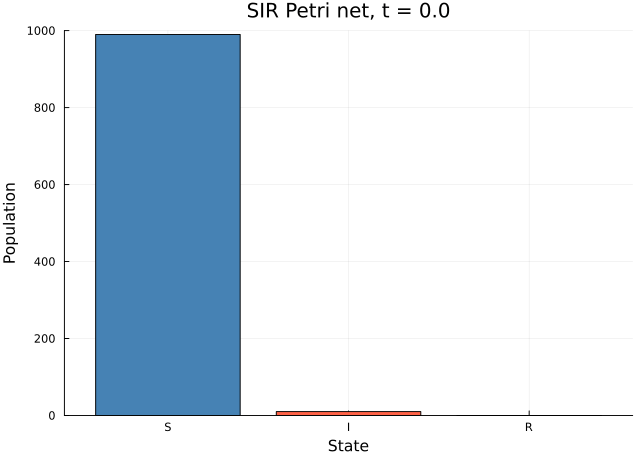

In [3]:
frame_step = max(1, floor(Int, size(df, 1) / 120))
df_frames = df[1:frame_step:end, :]

anim = @animate for row in eachrow(df_frames)
    bar(
        ["S", "I", "R"],
        [row.S, row.I, row.R],
        ylim = (0, sum(u0)),
        legend = false,
        xlabel = "State",
        ylabel = "Population",
        title = "SIR Petri net, t = $(round(row.time, digits = 1))",
        color = [:steelblue, :tomato, :seagreen],
    )
end

gif(anim, plotsdir("sir_animation.gif"), fps = 12)

# Вывод

Анимация показывает распространение эпидемии как движение маркировки по
состояниям сети Петри: сначала растёт число инфицированных, затем после
пика оно падает, а число выздоровевших выходит на плато.